In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F  
from pyspark.sql.types import *         

# rutas 
DATASET = "../dataset"
FIGURES = "../outputs/figures"
RESULTS = "../outputs/results"

# iniciamos spark en modo local
# porque es más rápido para el EDA y local usa todos los cores disponibles de la mac
spark = SparkSession.builder \
    .appName("Fase1-Preprocesamiento-EDA") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} listo")

# spark de docker usaremos para las siguientes fases
    # Fase 2: benchmark RDD vs DataFrame (necesitas workers reales para que tenga sentido)
    # Fase 3: MinHash y LSH sobre todo el dataset (carga distribuida real)
    # Fase 4: FP-Growth sobre 138K usuarios (idem)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/09 14:07:12 WARN Utils: Your hostname, Turing-Machine.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.46 instead (on interface en0)
26/05/09 14:07:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/09 14:07:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1 listo


# Carga

In [2]:
ratings = spark.read.csv(f"{DATASET}/ratings.csv", header=True, inferSchema=True)
movies  = spark.read.csv(f"{DATASET}/movies.csv",  header=True, inferSchema=True)
tags    = spark.read.csv(f"{DATASET}/tags.csv",    header=True, inferSchema=True)

# esquema
print("=== RATINGS ===")
ratings.printSchema()

print("=== MOVIES ===")
movies.printSchema()

print("=== TAGS ===")
tags.printSchema()

=== RATINGS ===
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

=== MOVIES ===
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

=== TAGS ===
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: integer (nullable = true)



In [3]:
ratings.show()
movies.show()
tags.show()

+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|      2|   3.5|1112486027|
|     1|     29|   3.5|1112484676|
|     1|     32|   3.5|1112484819|
|     1|     47|   3.5|1112484727|
|     1|     50|   3.5|1112484580|
|     1|    112|   3.5|1094785740|
|     1|    151|   4.0|1094785734|
|     1|    223|   4.0|1112485573|
|     1|    253|   4.0|1112484940|
|     1|    260|   4.0|1112484826|
|     1|    293|   4.0|1112484703|
|     1|    296|   4.0|1112484767|
|     1|    318|   4.0|1112484798|
|     1|    337|   3.5|1094785709|
|     1|    367|   3.5|1112485980|
|     1|    541|   4.0|1112484603|
|     1|    589|   3.5|1112485557|
|     1|    593|   3.5|1112484661|
|     1|    653|   3.0|1094785691|
|     1|    919|   3.5|1094785621|
+------+-------+------+----------+
only showing top 20 rows
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+-

> varias columnas requieren cambio de tipo de datos

# Inspección base

In [4]:
# registros 
print(f"Ratings: {ratings.count():,}")
print(f"Movies:  {movies.count():,}")
print(f"Tags:    {tags.count():,}")

# rango de valores de rating
print("\n--- Rango de ratings ---")
ratings.select(
    F.min("rating").alias("min"),
    F.max("rating").alias("max"),
    F.round(F.avg("rating"), 4).alias("promedio")
).show()

# cuántos usuarios y películas únicos hay en ratings
print("--- Usuarios y películas únicos en ratings ---")
ratings.select(
    F.countDistinct("userId").alias("usuarios_unicos"),
    F.countDistinct("movieId").alias("peliculas_unicas")
).show()

Ratings: 20,000,263
Movies:  27,278
Tags:    465,564

--- Rango de ratings ---


+---+---+--------+
|min|max|promedio|
+---+---+--------+
|0.5|5.0|  3.5255|
+---+---+--------+

--- Usuarios y películas únicos en ratings ---


+---------------+----------------+
|usuarios_unicos|peliculas_unicas|
+---------------+----------------+
|         138493|           26744|
+---------------+----------------+



> Hay 27,278 películas en movies.csv, pero en ratings.csv solo aparecen 26,744 películas únicas. Eso significa que 534 películas existen en el catálogo pero nunca recibieron un rating. 

# Nulos, inconsistentes o duplicados.

nulos

In [5]:
print("=== NULOS ===")
print("Ratings:")
ratings.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in ratings.columns]).show()

print("Movies:")
movies.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in movies.columns]).show()

print("Tags:")
tags.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in tags.columns]).show()


=== NULOS ===
Ratings:


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

Movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

Tags:
+------+-------+---+---------+
|userId|movieId|tag|timestamp|
+------+-------+---+---------+
|     0|      0|  0|        0|
+------+-------+---+---------+



duplicados

In [6]:
print("=== DUPLICADOS ===")
dup_ratings = ratings.count() - ratings.dropDuplicates(["userId", "movieId"]).count()
dup_movies  = movies.count()  - movies.dropDuplicates(["movieId"]).count()
dup_tags    = tags.count()    - tags.dropDuplicates(["userId", "movieId", "tag"]).count()

print(f"Ratings duplicados: {dup_ratings:,}")
print(f"Movies duplicados:  {dup_movies:,}")
print(f"Tags duplicados:    {dup_tags:,}")

=== DUPLICADOS ===


Ratings duplicados: 0
Movies duplicados:  0
Tags duplicados:    0


fuera de rango

In [7]:
# ratings fuera del rango válido (0.5 a 5.0 en pasos de 0.5)
print("=== Ratings fuera de rango ===")
ratings.filter((F.col("rating") < 0.5) | (F.col("rating") > 5.0)).show()

# valores distintos de rating para ver si hay medios pasos correctos
print("=== Valores únicos de rating ===")
ratings.groupBy("rating").count().orderBy("rating").show()

# películas sin género asignado
print("=== Películas sin género ===")
movies.filter(
    (F.col("genres").isNull()) |
    (F.col("genres") == "") |
    (F.col("genres") == "(no genres listed)")
).show(10, truncate=False)



=== Ratings fuera de rango ===


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
+------+-------+------+---------+

=== Valores únicos de rating ===


+------+-------+
|rating|  count|
+------+-------+
|   0.5| 239125|
|   1.0| 680732|
|   1.5| 279252|
|   2.0|1430997|
|   2.5| 883398|
|   3.0|4291193|
|   3.5|2200156|
|   4.0|5561926|
|   4.5|1534824|
|   5.0|2898660|
+------+-------+

=== Películas sin género ===
+-------+-----------------------------------------------+------------------+
|movieId|title                                          |genres            |
+-------+-----------------------------------------------+------------------+
|83773  |Away with Words (San tiao ren) (1999)          |(no genres listed)|
|83829  |Scorpio Rising (1964)                          |(no genres listed)|
|84768  |Glitterbug (1994)                              |(no genres listed)|
|86493  |Age of the Earth, The (A Idade da Terra) (1980)|(no genres listed)|
|87061  |Trails (Veredas) (1978)                        |(no genres listed)|
|91246  |Milky Way (Tejút) (2007)                       |(no genres listed)|
|92435  |Dancing Hawk, The (Tanczacy ja

In [8]:
# conteo total de películas sin género
sin_genero = movies.filter(F.col("genres") == "(no genres listed)").count()
print(f"Películas sin género: {sin_genero:,}")

# conteo de tags vacíos (resultado que se cortó)
tags_vacios = tags.filter(
    (F.col("tag").isNull()) | (F.trim(F.col("tag")) == "")
).count()
print(f"Tags vacíos: {tags_vacios:,}")

Películas sin género: 246
Tags vacíos: 0


> Sin nulos, sin duplicados, sin ratings fuera de rango

> 534 películas en el catálogo que nunca fueron calificadas

> 246 películas sin género asignado

> Géneros separados por | que hay que separar

> timestamp en formato Unix que hay que convertir a fecha

## Visualización de distribuciones

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# estilo
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("matplotlib listo")

matplotlib listo


### distribución de ratings

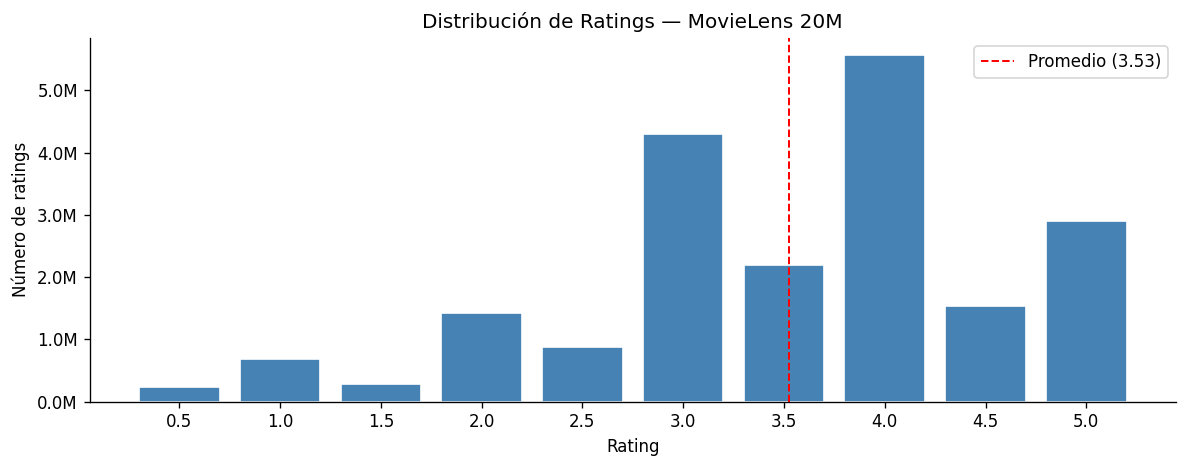

Guardado: 01_distribucion_ratings.png


In [10]:
# Traemos los conteos al driver (son solo 10 filas, seguro hacerlo con toPandas)
dist_ratings = ratings.groupBy("rating").count().orderBy("rating").toPandas()

fig, ax = plt.subplots()

bars = ax.bar(
    dist_ratings["rating"],
    dist_ratings["count"],
    width=0.4,
    color="steelblue",
    edgecolor="white"
)

# Línea vertical en el promedio
ax.axvline(x=3.5255, color="red", linestyle="--", linewidth=1.2, label="Promedio (3.53)")

ax.set_xlabel("Rating")
ax.set_ylabel("Número de ratings")
ax.set_title("Distribución de Ratings — MovieLens 20M")
ax.set_xticks(dist_ratings["rating"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIGURES}/01_distribucion_ratings.png", bbox_inches="tight")
plt.show()

print("Guardado: 01_distribucion_ratings.png")

> los usuarios tienden a calificar positivamente

> los usuarios prefieren números redondos.

> El promedio de 3.53 cae justo entre 3.5 y 4.0, lo que justifica usar 3.5 como umbral de binarización 

### ratings por usuario

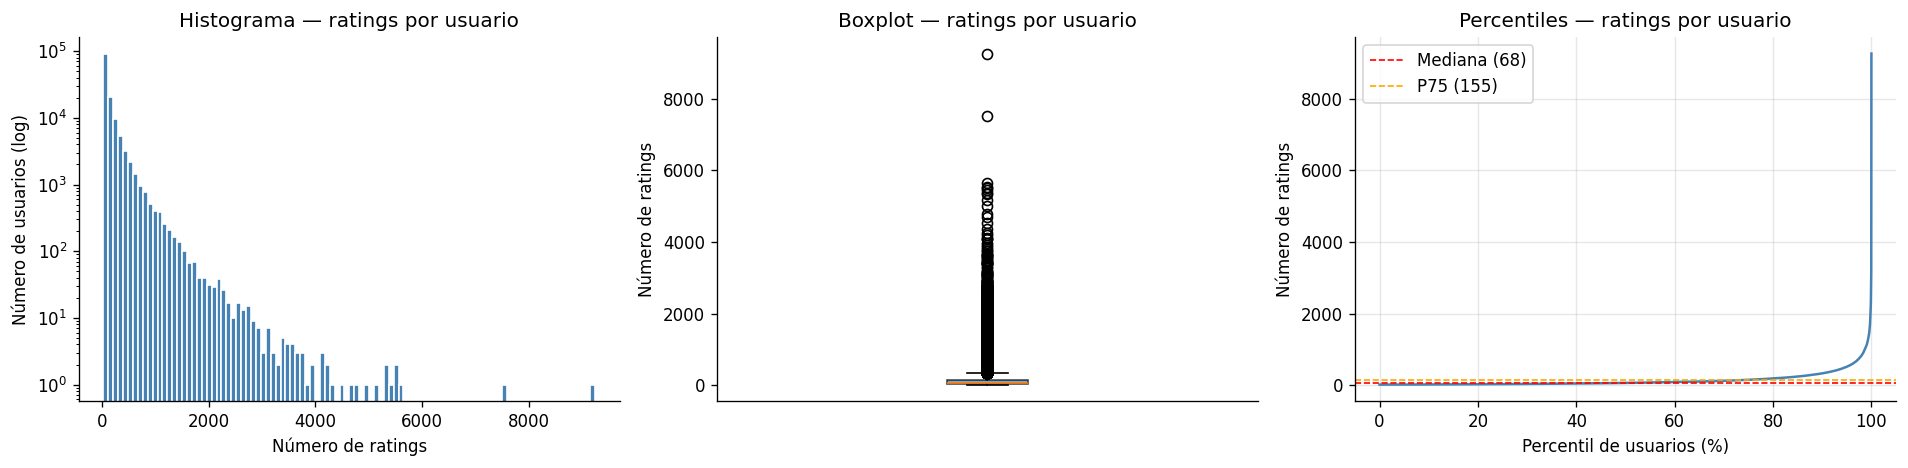

count    138,493
mean         144
std          230
min           20
25%           35
50%           68
75%          155
max        9,254
Name: count, dtype: object


In [11]:
ratings_x_usuario = ratings.groupBy("userId").count().toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Histograma ---
axes[0].hist(ratings_x_usuario["count"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_xlabel("Número de ratings")
axes[0].set_ylabel("Número de usuarios (log)")
axes[0].set_title("Histograma — ratings por usuario")

# --- Boxplot ---
axes[1].boxplot(ratings_x_usuario["count"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7))
axes[1].set_ylabel("Número de ratings")
axes[1].set_title("Boxplot — ratings por usuario")
axes[1].set_xticks([])

# --- Curva de percentiles ---
ordenados = ratings_x_usuario["count"].sort_values().reset_index(drop=True)
percentiles = (ordenados.index / len(ordenados)) * 100

axes[2].plot(percentiles, ordenados, color="steelblue", linewidth=1.5)
axes[2].set_xlabel("Percentil de usuarios (%)")
axes[2].set_ylabel("Número de ratings")
axes[2].set_title("Percentiles — ratings por usuario")
axes[2].axhline(y=68,  color="red",    linestyle="--", linewidth=1, label="Mediana (68)")
axes[2].axhline(y=155, color="orange", linestyle="--", linewidth=1, label="P75 (155)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{FIGURES}/02_ratings_por_usuario.png", bbox_inches="tight")
plt.show()

print(ratings_x_usuario["count"].describe().apply(lambda x: f"{x:,.0f}"))

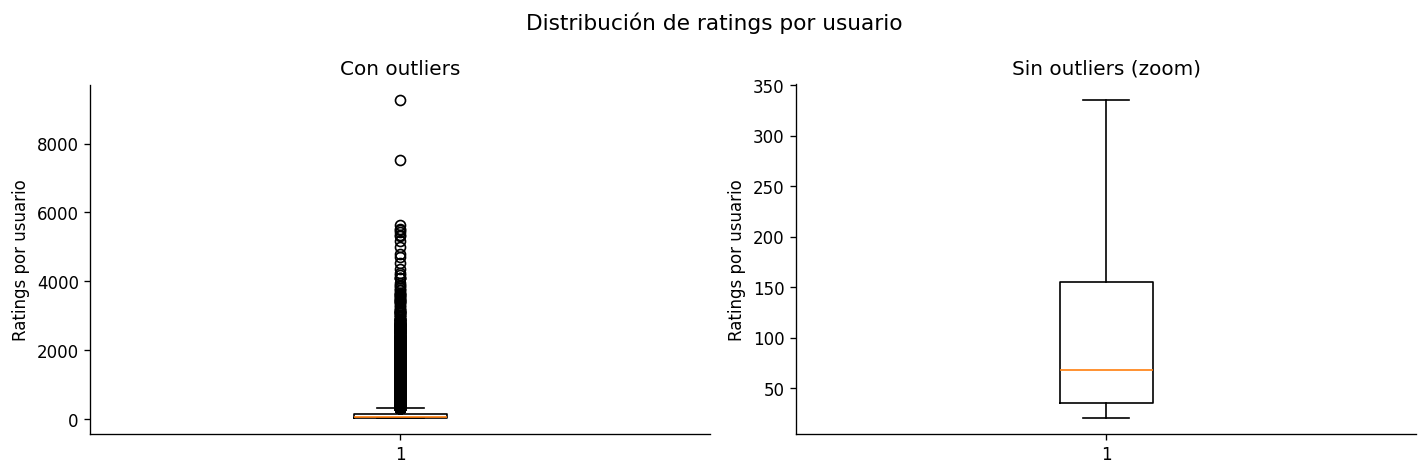

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# con outliers
axes[0].boxplot(ratings_x_usuario["count"], vert=True)
axes[0].set_title("Con outliers")
axes[0].set_ylabel("Ratings por usuario")

# sin outliers
axes[1].boxplot(ratings_x_usuario["count"], vert=True, showfliers=False)
axes[1].set_title("Sin outliers (zoom)")
axes[1].set_ylabel("Ratings por usuario")

plt.suptitle("Distribución de ratings por usuario", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES}/02b_boxplot_zoom.png", bbox_inches="tight")
plt.show()

> La mayoría de usuarios tiene pocos ratings, muy pocos tienen miles.

> No aporta mucho. El 75% de usuarios tiene entre 20 y 155 ratings. Los outliers son usuarios que calificaron más de 7,500 y 9,254 películas 

### rating por película

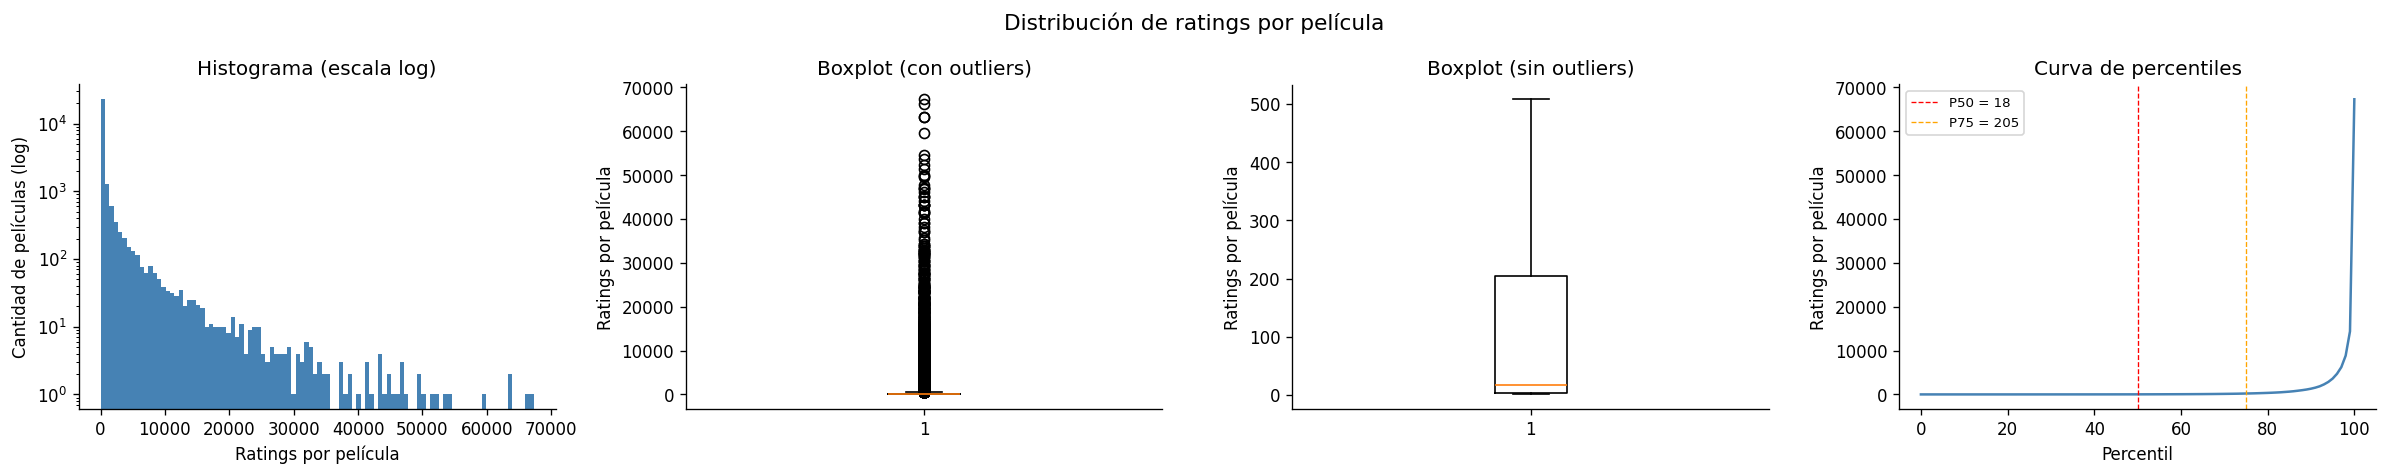

In [13]:
ratings_x_pelicula = ratings.groupBy("movieId").count().toPandas()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. Histograma en escala log
axes[0].hist(ratings_x_pelicula["count"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_yscale("log")
axes[0].set_xlabel("Ratings por película")
axes[0].set_ylabel("Cantidad de películas (log)")
axes[0].set_title("Histograma (escala log)")

# 2. Boxplot con outliers
axes[1].boxplot(ratings_x_pelicula["count"], vert=True)
axes[1].set_ylabel("Ratings por película")
axes[1].set_title("Boxplot (con outliers)")

# 3. Boxplot sin outliers
axes[2].boxplot(ratings_x_pelicula["count"], vert=True, showfliers=False)
axes[2].set_ylabel("Ratings por película")
axes[2].set_title("Boxplot (sin outliers)")

# 4. Curva de percentiles
percentiles = range(0, 101)
valores = [ratings_x_pelicula["count"].quantile(p / 100) for p in percentiles]
axes[3].plot(percentiles, valores, color="steelblue")
axes[3].axvline(50, color="red",    linestyle="--", linewidth=0.8, label=f"P50 = {ratings_x_pelicula['count'].median():.0f}")
axes[3].axvline(75, color="orange", linestyle="--", linewidth=0.8, label=f"P75 = {ratings_x_pelicula['count'].quantile(0.75):.0f}")
axes[3].set_xlabel("Percentil")
axes[3].set_ylabel("Ratings por película")
axes[3].set_title("Curva de percentiles")
axes[3].legend(fontsize=8)

plt.suptitle("Distribución de ratings por película", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES}/03_ratings_por_pelicula.png", bbox_inches="tight")
plt.show()

In [14]:
print(ratings_x_pelicula["count"].describe().apply(lambda x: f"{x:,.0f}"))

count    26,744
mean        748
std       3,086
min           1
25%           3
50%          18
75%         205
max      67,310
Name: count, dtype: object


> P50 = 18 ratings → la mitad de las películas tiene 18 ratings o menos. Son películas de nicho que casi nadie calificó.

> P75 = 205 ratings → el 75% de las películas tiene menos de 205 ratings.

> La curva de percentiles muestra que el top 25% de películas concentra casi todos los ratings del dataset.

> El boxplot con outliers muestra que hay películas con aprox 67,000 ratings, o sea son películas icónicas (Pulp fiction, forrest gump, etc)

### Géneros por películas

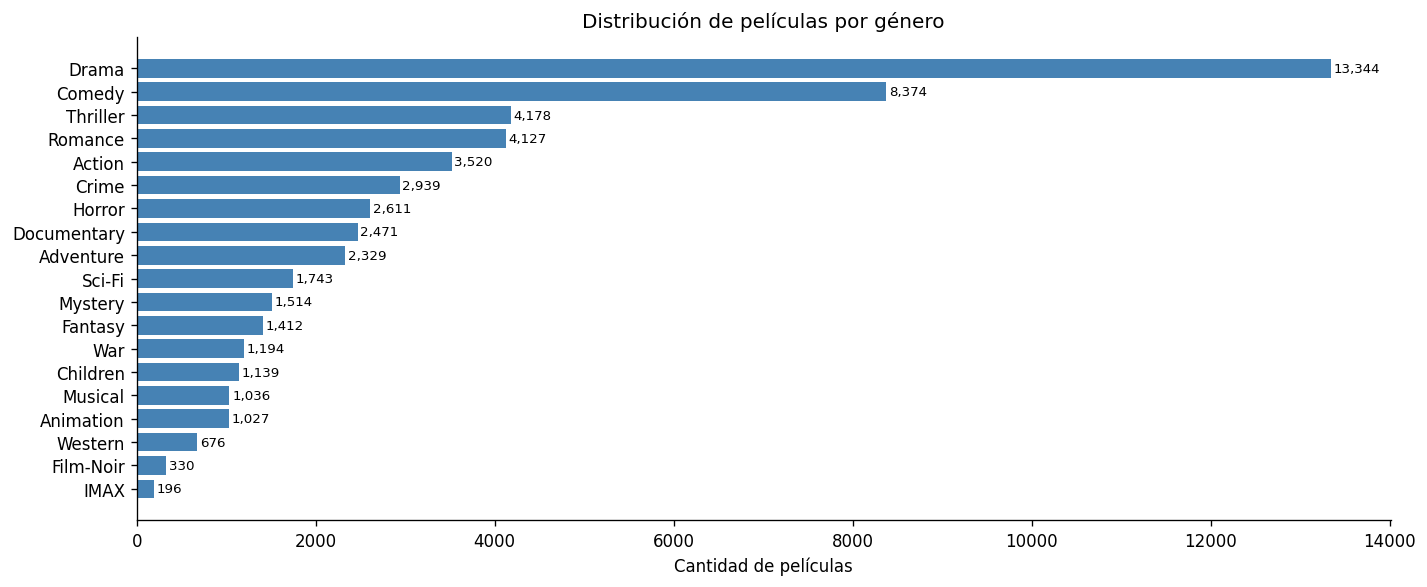

In [15]:
from pyspark.sql.functions import explode, split, col, count

generos = movies.withColumn("genero", explode(split(col("genres"), "\\|")))

# filtrar "no genres listed" 
conteo_generos = (generos
    .filter(col("genero") != "(no genres listed)")
    .groupBy("genero")
    .agg(count("*").alias("cantidad"))
    .orderBy("cantidad", ascending=False)
    .toPandas()
)


fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(conteo_generos["genero"], conteo_generos["cantidad"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Cantidad de películas")
ax.set_title("Distribución de películas por género")

# labels
for i, (val, gen) in enumerate(zip(conteo_generos["cantidad"], conteo_generos["genero"])):
    ax.text(val + 30, i, f"{val:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES}/04_distribucion_generos.png", bbox_inches="tight")
plt.show()

> Drama domina con 13,344 películas, casi el doble que Comedy (8,374). Juntos representan más del 50% del catálogo.

> Western (676), Film-Noir (330) e IMAX (196) son géneros muy de nicho. IMAX en particular no es un género real sino un formato

> Como una película puede tener varios géneros a la vez, estos números no suman el total de películas (hay solapamiento) 

> Mas adelante, en FP-Growth cada película será una "transacción" con sus géneros como "ítems", donde los géneros pueden aparecer como ítems frecuentes en reglas de asociación tipo "películas de Drama también suelen ser Romance".

### Dispersión de los datos

In [16]:
from pyspark.sql.functions import countDistinct

# Valores ya conocidos de la inspección inicial
total_usuarios = 138493
total_peliculas = 26744
total_ratings = 20000263

# Sparsity
celdas_totales = total_usuarios * total_peliculas
sparsity = 1 - (total_ratings / celdas_totales)

print(f"Matriz: {total_usuarios:,} usuarios × {total_peliculas:,} películas")
print(f"Celdas totales:  {celdas_totales:,}")
print(f"Celdas con dato: {total_ratings:,}")
print(f"Sparsity:        {sparsity:.4%}")




Matriz: 138,493 usuarios × 26,744 películas
Celdas totales:  3,703,856,792
Celdas con dato: 20,000,263
Sparsity:        99.4600%


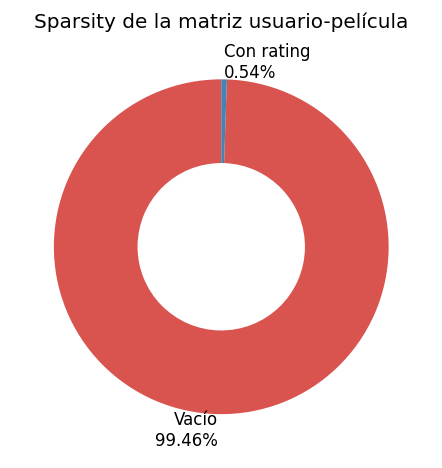

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

valores = [sparsity * 100, (1 - sparsity) * 100]
etiquetas = [f"Vacío\n{sparsity:.2%}", f"Con rating\n{(1-sparsity):.2%}"]
colores = ["#d9534f", "steelblue"]

ax.pie(valores, labels=etiquetas, colors=colores, startangle=90,
       wedgeprops=dict(width=0.5))
ax.set_title("Sparsity de la matriz usuario-película")

plt.tight_layout()
plt.savefig(f"{FIGURES}/05_sparsity.png", bbox_inches="tight")
plt.show()

> Tendríamos una tabla donde cada fila es un usuario (138K), cada columna es una película (27K) y por ende, la tabla tiene 3,700 millones de celdas en total (rating que ese usuario le dio a esa película)

> Pero los usuarios solo dejaron 20 millones de ratings. El resto nunca las vieron o nunca las calificaron.

> Significa que el 99.46% de la tabla está vacía.

> Esto justifica usar técnicas como MinHash y LSH, ya que no hay suficientes datos compartidos entre usuarios para comparar bien; ademas, se vuelve muy costoso cuando la matriz está tan vacía. La matriz es sparse

### Evolución temporal

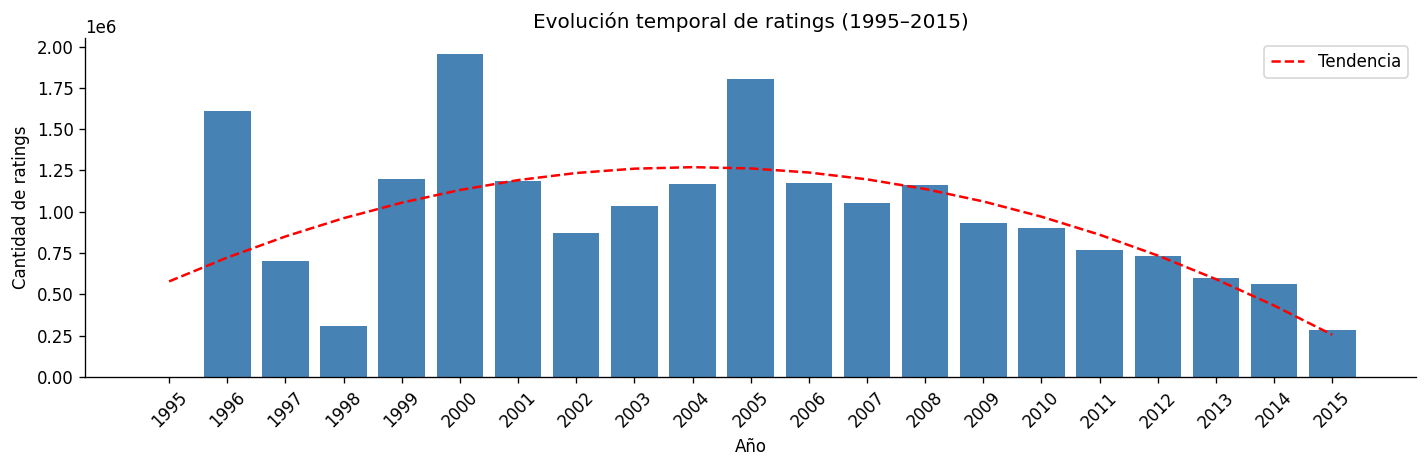

In [18]:
from pyspark.sql.functions import from_unixtime, year, count

# jalamos año del timestamp (formato Unix)
ratings_por_anio = (ratings
    .withColumn("anio", year(from_unixtime(col("timestamp"))))
    .groupBy("anio")
    .agg(count("*").alias("cantidad"))
    .orderBy("anio")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(ratings_por_anio["anio"], ratings_por_anio["cantidad"],
       color="steelblue", edgecolor="none")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de ratings")
ax.set_title("Evolución temporal de ratings (1995–2015)")
ax.set_xticks(ratings_por_anio["anio"])
ax.set_xticklabels(ratings_por_anio["anio"], rotation=45)

# tendencia
import numpy as np
z = np.polyfit(ratings_por_anio["anio"], ratings_por_anio["cantidad"], 2)
p = np.poly1d(z)
ax.plot(ratings_por_anio["anio"], p(ratings_por_anio["anio"]),
        color="red", linewidth=1.5, linestyle="--", label="Tendencia")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIGURES}/06_evolucion_temporal.png", bbox_inches="tight")
plt.show()

> **Picos en 2000 y 2005:** coinciden con el boom del DVD y el crecimiento de plataformas de recomendación online.

> **Caída post-2005:** usuarios migraron a otras plataformas como Netflix y YouTube.

> **2015 es bajo porque el dataset fue exportado a mitad de año** — solo tiene datos parciales, no es una caída real.


### Tags

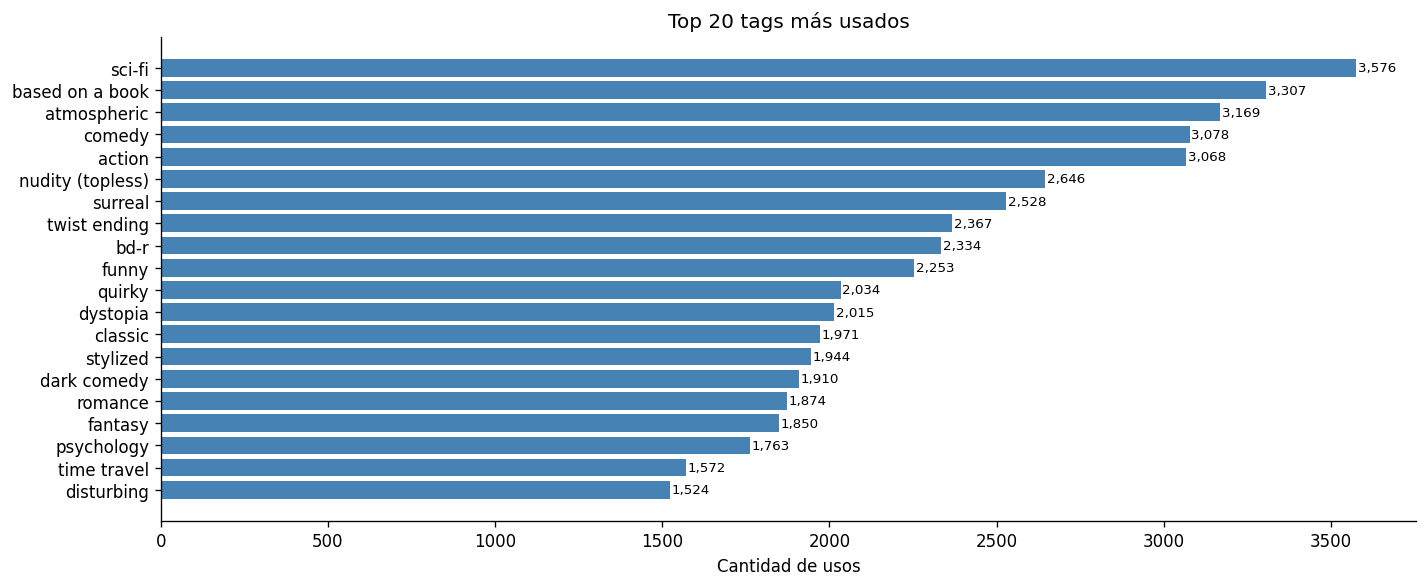

In [19]:
from pyspark.sql.functions import lower, trim

top_tags = (tags
    .withColumn("tag", lower(trim(col("tag"))))
    .groupBy("tag")
    .agg(count("*").alias("cantidad"))
    .orderBy("cantidad", ascending=False)
    .limit(20)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(top_tags["tag"], top_tags["cantidad"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Cantidad de usos")
ax.set_title("Top 20 tags más usados")

for i, val in enumerate(top_tags["cantidad"]):
    ax.text(val + 5, i, f"{val:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES}/07_top_tags.png", bbox_inches="tight")
plt.show()

> **sci-fi domina con 3,576 usos** — los usuarios tienen fuerte preferencia por ciencia ficción.

> **Tags de género vs. descriptivos** — comedy, action, romance repiten géneros del catálogo; atmospheric, surreal, twist ending describen estilo o experiencia.

> Los usuarios etiquetan activamente adaptaciones literarias.

> bd-r es candidato a eliminar en preprocesamiento porque no describe la película. Es Blu-ray Disc .

> Estos tags sirven como representación de películas para calcular similitud Jaccard.

# Pre procesamiento

1. Limpieza

    -  Marcaremos las 246 películas sin género como "Unknown"
    -  Eliminaremos tags técnicos como "bd-r"

2. Binarización de ratings

    -  Convertiremos ratings numéricos (0.5–5.0) a like/dislike
    -  Definimos Umbral: rating ≥ 3.5 → like (1), rating < 3.5 → dislike (0)
        -  Justificación: 3.5 es la media del dataset, además es el punto donde el usuario conscientemente da media estrella extra

3. Guardamos en Parquet

    -  ratings_clean.parquet -> con columna binaria añadida
    -  movies_clean.parquet -> con géneros corregidos

## Limpieza

Limpieza para movies

In [20]:
from pyspark.sql.functions import when

# reemplazar "(no genres listed)" por "Unknown"
movies_clean = movies.withColumn(
    "genres",
    when(col("genres") == "(no genres listed)", "Unknown").otherwise(col("genres"))
)

# Verificar
movies_clean.filter(col("genres") == "Unknown").count()

246

Limpieza de tags

In [21]:
# eliminar tags técnicos y limpiar texto
tags_clean = (tags
    .withColumn("tag", lower(trim(col("tag"))))
    .filter(col("tag") != "bd-r")
)

# cantidad de eliminados
print(f"Tags originales:  {tags.count():,}")
print(f"Tags después:     {tags_clean.count():,}")

Tags originales:  465,564
Tags después:     463,230


> eliminamos 2,334 tags de bd-r

## Binarización

In [22]:
# agregamos la columna binaria: 1 = like (≥3.5), 0 = dislike (<3.5)
ratings_clean = ratings.withColumn(
    "like",
    when(col("rating") >= 3.5, 1).otherwise(0)
)

# verificamos distribución like/dislike
ratings_clean.groupBy("like").count().orderBy("like").show()

+----+--------+
|like|   count|
+----+--------+
|   0| 7804697|
|   1|12195566|
+----+--------+



> 61% likes y 39% dislikes

## Unificación de géneros 

In [23]:
from pyspark.sql.functions import explode, split

(movies_clean
    .withColumn("genero", explode(split(col("genres"), "\\|")))
    .select("genero")
    .distinct()
    .orderBy("genero")
    .show(30, truncate=False)
)

+-----------+
|genero     |
+-----------+
|Action     |
|Adventure  |
|Animation  |
|Children   |
|Comedy     |
|Crime      |
|Documentary|
|Drama      |
|Fantasy    |
|Film-Noir  |
|Horror     |
|IMAX       |
|Musical    |
|Mystery    |
|Romance    |
|Sci-Fi     |
|Thriller   |
|Unknown    |
|War        |
|Western    |
+-----------+



In [24]:
from pyspark.sql.functions import regexp_replace

# unificación de etiquetas de géneros
movies_clean = (movies_clean
    .withColumn("genres", regexp_replace(col("genres"), "Sci-Fi", "Science Fiction"))
    .withColumn("genres", regexp_replace(col("genres"), "Film-Noir", "Film Noir"))
    .withColumn("genres", regexp_replace(col("genres"), "Children", "Children's"))
)

# eliminamos IMAX 
movies_clean = (movies_clean
    .withColumn("genres", regexp_replace(col("genres"), r"\|IMAX", ""))  # IMAX al final: "Drama|IMAX"
    .withColumn("genres", regexp_replace(col("genres"), r"IMAX\|", ""))  # IMAX al inicio: "IMAX|Drama"
    .withColumn("genres", regexp_replace(col("genres"), "IMAX", ""))     # IMAX solo
)

# verificar
(movies_clean
    .withColumn("genero", explode(split(col("genres"), "\\|")))
    .select("genero")
    .distinct()
    .orderBy("genero")
    .show(30, truncate=False)
)

+---------------+
|genero         |
+---------------+
|               |
|Action         |
|Adventure      |
|Animation      |
|Children's     |
|Comedy         |
|Crime          |
|Documentary    |
|Drama          |
|Fantasy        |
|Film Noir      |
|Horror         |
|Musical        |
|Mystery        |
|Romance        |
|Science Fiction|
|Thriller       |
|Unknown        |
|War            |
|Western        |
+---------------+



In [25]:
# películas que quedaron con generio vacío las llamamos Unknown
movies_clean = movies_clean.withColumn(
    "genres",
    when((col("genres") == "") | (col("genres").isNull()), "Unknown").otherwise(col("genres"))
)


movies_clean.filter(col("genres") == "Unknown").count()

247

> Sci-Fi → Science Fiction, Film-Noir → Film Noir, Children → Children's (estandarización de nombres)

> IMAX se elimina porque es un género

## Guardado

In [26]:
# Usamos RESULTS definido al inicio del notebook (ruta relativa portable)
ratings_clean.write.mode("overwrite").parquet(f"{RESULTS}/ratings_clean.parquet")
movies_clean.write.mode("overwrite").parquet(f"{RESULTS}/movies_clean.parquet")
tags_clean.write.mode("overwrite").parquet(f"{RESULTS}/tags_clean.parquet")

print(" Guardado completo")

 Guardado completo


verficamos

In [27]:
ratings_v = spark.read.parquet(f"{RESULTS}/ratings_clean.parquet")
movies_v  = spark.read.parquet(f"{RESULTS}/movies_clean.parquet")
tags_v    = spark.read.parquet(f"{RESULTS}/tags_clean.parquet")

print(f"ratings_clean: {ratings_v.count():,} filas")
print(f"movies_clean:  {movies_v.count():,} filas")
print(f"tags_clean:    {tags_v.count():,} filas")

ratings_clean: 20,000,263 filas
movies_clean:  27,278 filas
tags_clean:    463,230 filas


In [28]:
ratings_v.printSchema()
movies_v.printSchema()
tags_v.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)
 |-- like: integer (nullable = true)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: integer (nullable = true)



> matenemos timestamp → integer porque no haremos operaciones de tiempo y solo fue usado para sacar el año

> las variables ID lo dejamos como integer. String ocuparía más memoria y los joins/groupBy serían más lentos

**Tareas completadas**

-   Nulos, duplicados e inconsistencias revisados
-   246 + 1 películas sin género → Unknown
-   Géneros unificados (Sci-Fi → Science Fiction, Film-Noir → Film Noir, Children → Children's)
-   IMAX eliminado
-   Tags técnicos (bd-r) eliminados
-   Binarización con umbral 3.5 justificado
-   3 Parquet limpios guardados

In [29]:
spark.stop()